# Random Forest — Advanced Features + Interactive EDA Analysis + Unsupervised Lab

**Rules honoured:**
- No `def` / no lambdas in notebook cells (all logic in `src/` modules or bound methods).
- Encoding strategies (binary / ordinal / onehot-drop-first / target) inside `AdvancedEVFeatureExtractor`.
- Native `roc_auc` scorer (version-proof).
- **Interactive Analysis Studio**: compare any two features, filter derived-vs-original importance groups, sweep threshold & segments.
- Empty cells between logical blocks.

In [1]:
import os
import sys
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

current_dir = os.getcwd()
workspace_root = current_dir
if os.path.basename(current_dir) == 'notebooks':
    workspace_root = os.path.dirname(current_dir)
src_path = os.path.join(workspace_root, 'src')
sys.path.insert(0, workspace_root)
sys.path.insert(0, src_path)

kaggle_input = Path('/kaggle/input')
if kaggle_input.exists():
    for py_file in kaggle_input.rglob('*.py'):
        sys.path.insert(0, str(py_file.parent))

from sklearn.model_selection import (StratifiedKFold, StratifiedShuffleSplit, train_test_split, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.base import clone
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
    SKOPT_AVAILABLE = True
except ImportError:
    SKOPT_AVAILABLE = False

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

import importlib

from ev_baseline_utils import EVFeatureExtractor, competition_score
from ev_data_utils import load_ev_data

try:
    import ev_advanced_utils
    import ev_cluster_utils
    import ev_analysis_utils
    import ev_interactive_utils
    for _mod in (ev_advanced_utils, ev_cluster_utils, ev_analysis_utils, ev_interactive_utils):
        importlib.reload(_mod)
    AdvancedEVFeatureExtractor = ev_advanced_utils.AdvancedEVFeatureExtractor
    ClusterExplorer = ev_cluster_utils.ClusterExplorer
    SignalRanker = ev_analysis_utils.SignalRanker
    CorrelationStudio = ev_analysis_utils.CorrelationStudio
    DerivedVsOriginalAudit = ev_analysis_utils.DerivedVsOriginalAudit
    PredictionDiagnostics = ev_analysis_utils.PredictionDiagnostics
    EDASegmentAuditor = ev_analysis_utils.EDASegmentAuditor
    InteractiveAnalysisStudio = ev_interactive_utils.InteractiveAnalysisStudio
    print('✅ All advanced, analysis & interactive modules imported (reloaded from src/).')
except ImportError as e:
    print(f'⚠️ Missing modules in src/: {e}')

✅ All advanced, analysis & interactive modules imported (reloaded from src/).


In [2]:
TARGET_COL = 'Will_Buy_EV'
RANDOM_STATE = 42
N_SPLITS = 1
HOLDOUT_SIZE = 0.4
MAKE_SUBMISSION = True
SEARCH_MODE = 'grid'
N_ITER = 15
VERBOSE = 1
ERROR_SCORE = 'raise'
USE_BAYESIAN = SEARCH_MODE == 'bayesian' and SKOPT_AVAILABLE

SMOKE_TEST = True
SUBSAMPLE_SEARCH = True
SEARCH_CAP = 6000 if SMOKE_TEST else 120000
RF_N_EST = 40 if SMOKE_TEST else 150
SEL_N_EST = 20 if SMOKE_TEST else 80
RUN_CLUSTER_EXPLORER = True

results_dir = Path('results')
results_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
print(f'Search mode: {SEARCH_MODE} | SMOKE_TEST={SMOKE_TEST} | widgets={WIDGETS_AVAILABLE}')

Search mode: grid | SMOKE_TEST=True | widgets=True


In [3]:
train_df, test_df, data_source = load_ev_data(
    local_dir='data', train_name='train.csv', test_name='test.csv',
    sample_name='sample_ev.csv', target_col=TARGET_COL,
)
print(f'✅ Data source: {data_source}')
print(f'Train shape: {train_df.shape}')
if test_df is not None: print(f'Test shape: {test_df.shape}')

train_df = train_df.dropna(subset=[TARGET_COL]).copy()
train_df[TARGET_COL] = train_df[TARGET_COL].astype(int)
X = train_df.drop(columns=[TARGET_COL], errors='ignore').copy()
y = train_df[TARGET_COL].astype(int).copy()

if len(X) > 2000:
    X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=HOLDOUT_SIZE, stratify=y, random_state=RANDOM_STATE)
    DO_HOLDOUT = True
else:
    X_train, y_train = X, y
    X_holdout, y_holdout, DO_HOLDOUT = None, None, False
print(f'\nTrain rows: {len(X_train)} | Holdout rows: {len(X_holdout) if DO_HOLDOUT else 0}')

✅ Found data folder: C:\Users\maran\OneDrive\Documents\Git Profile\Data-Projects\evpurchase_kaggle\data
✅ Data source: Train file: C:\Users\maran\OneDrive\Documents\Git Profile\Data-Projects\evpurchase_kaggle\data\train.csv
Train shape: (668665, 15)
Test shape: (286571, 14)

Train rows: 401199 | Holdout rows: 267466


In [4]:
rf_pipeline = Pipeline([
    ('extractor', AdvancedEVFeatureExtractor(
        feature_set='multivariate',
        target_col=TARGET_COL,
        drop_id=True,
        impute_strategy='median',
        scale_numeric=False,
        onehot_categorical=True,
        add_derived_features=True,
        add_advanced_features=True,
        add_domain_features=True,
        add_recipe_features=True,
        add_eda_rules=True,
        add_digit_features=True,
        categorical_strategy='auto',
        extra_encodings=True,
    )),
    ('selector', SelectFromModel(
        estimator=ExtraTreesClassifier(
            n_estimators=SEL_N_EST,
            max_depth=12,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        threshold='mean',
    )),
    ('model', RandomForestClassifier(
        n_estimators=RF_N_EST,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
print('✅ Created Advanced Random Forest pipeline (extractor -> selector -> model).')

✅ Created Advanced Random Forest pipeline (extractor -> selector -> model).


In [5]:
X_s, _, y_s, _ = train_test_split(X_train, y_train, train_size=min(4000, len(X_train)), stratify=y_train, random_state=RANDOM_STATE)
sanity = clone(rf_pipeline)
sanity.fit(X_s, y_s)
enc_w = sanity.named_steps['extractor'].transform(X_s).shape[1]
sel_n = int(sanity.named_steps['selector'].get_support().sum())
print(f'encoded width={enc_w} | selected={sel_n} | dropped={enc_w - sel_n}')
print(f'sanity ROC AUC: {roc_auc_score(y_s, sanity.predict_proba(X_s)[:, 1]):.4f}')
del sanity, X_s, y_s

encoded width=70 | selected=12 | dropped=58
sanity ROC AUC: 0.9980


In [6]:
scorer = 'roc_auc'
print('✅ Using native ROC AUC scorer.')

✅ Using native ROC AUC scorer.


In [7]:
RF_GRID_SPACE = {
    'extractor__add_derived_features': [True, False],
    'extractor__add_digit_features': [True, False],
    'extractor__categorical_strategy': ['auto', 'onehot_drop_first'],
    'selector__threshold': [1e-12, 'mean'],
    'model__max_depth': [None, 20],
}

if SMOKE_TEST:
    RF_GRID_SPACE = {
        'model__max_depth': [None, 5],
        'selector__threshold': ['mean'],
    }

if SKOPT_AVAILABLE:
    RF_BAYESIAN_SPACE = {
        'extractor__add_derived_features': Categorical([True, False]),
        'extractor__add_digit_features': Categorical([True, False]),
        'extractor__categorical_strategy': Categorical(['auto', 'onehot_drop_first', 'ordinal']),
        'selector__threshold': Categorical([1e-12, 'mean', 'median']),
        'model__max_depth': Categorical([None, 15, 25]),
        'model__min_samples_leaf': Integer(1, 4),
    }
else:
    RF_BAYESIAN_SPACE = None

In [8]:
CAN_CV = (y_train.nunique() > 1 and len(y_train) >= 4 and int(y_train.value_counts().min()) >= 2)
if CAN_CV:
    if N_SPLITS == 1:
        cv_object = StratifiedShuffleSplit(n_splits=1, test_size=HOLDOUT_SIZE, random_state=RANDOM_STATE)
    else:
        n_splits = max(2, min(N_SPLITS, int(y_train.value_counts().min())))
        cv_object = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
else:
    cv_object = None

In [9]:
if CAN_CV:
    if SUBSAMPLE_SEARCH and len(X_train) > SEARCH_CAP:
        X_search, _, y_search, _ = train_test_split(X_train, y_train, train_size=SEARCH_CAP, stratify=y_train, random_state=RANDOM_STATE)
        print(f'⚡ Searching on stratified subsample: {len(X_search):,} rows')
    else:
        X_search, y_search = X_train, y_train
    if USE_BAYESIAN:
        rf_search = BayesSearchCV(rf_pipeline, RF_BAYESIAN_SPACE, n_iter=N_ITER, scoring=scorer, cv=cv_object, n_jobs=1, random_state=RANDOM_STATE, verbose=VERBOSE, error_score=ERROR_SCORE)
    else:
        rf_search = GridSearchCV(rf_pipeline, RF_GRID_SPACE, scoring=scorer, cv=cv_object, n_jobs=1, verbose=VERBOSE, error_score=ERROR_SCORE)
    rf_search.fit(X_search, y_search)
    BEST_PIPELINE = rf_search.best_estimator_
    SEARCH_SCORE = float(rf_search.best_score_)
    print('Best params:', rf_search.best_params_)
    print('🔁 Refitting best pipeline on FULL train split...')
    BEST_PIPELINE.fit(X_train, y_train)
else:
    BEST_PIPELINE = rf_pipeline
    BEST_PIPELINE.fit(X_train, y_train)
    SEARCH_SCORE = roc_auc_score(y_train, BEST_PIPELINE.predict_proba(X_train)[:, 1])
print(f'SEARCH_SCORE={SEARCH_SCORE:.4f}')

⚡ Searching on stratified subsample: 6,000 rows
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Best params: {'model__max_depth': 5, 'selector__threshold': 'mean'}
🔁 Refitting best pipeline on FULL train split...
SEARCH_SCORE=0.9330


# Holdout Error Dashboard

🔎 Selector kept 12/70 encoded columns.


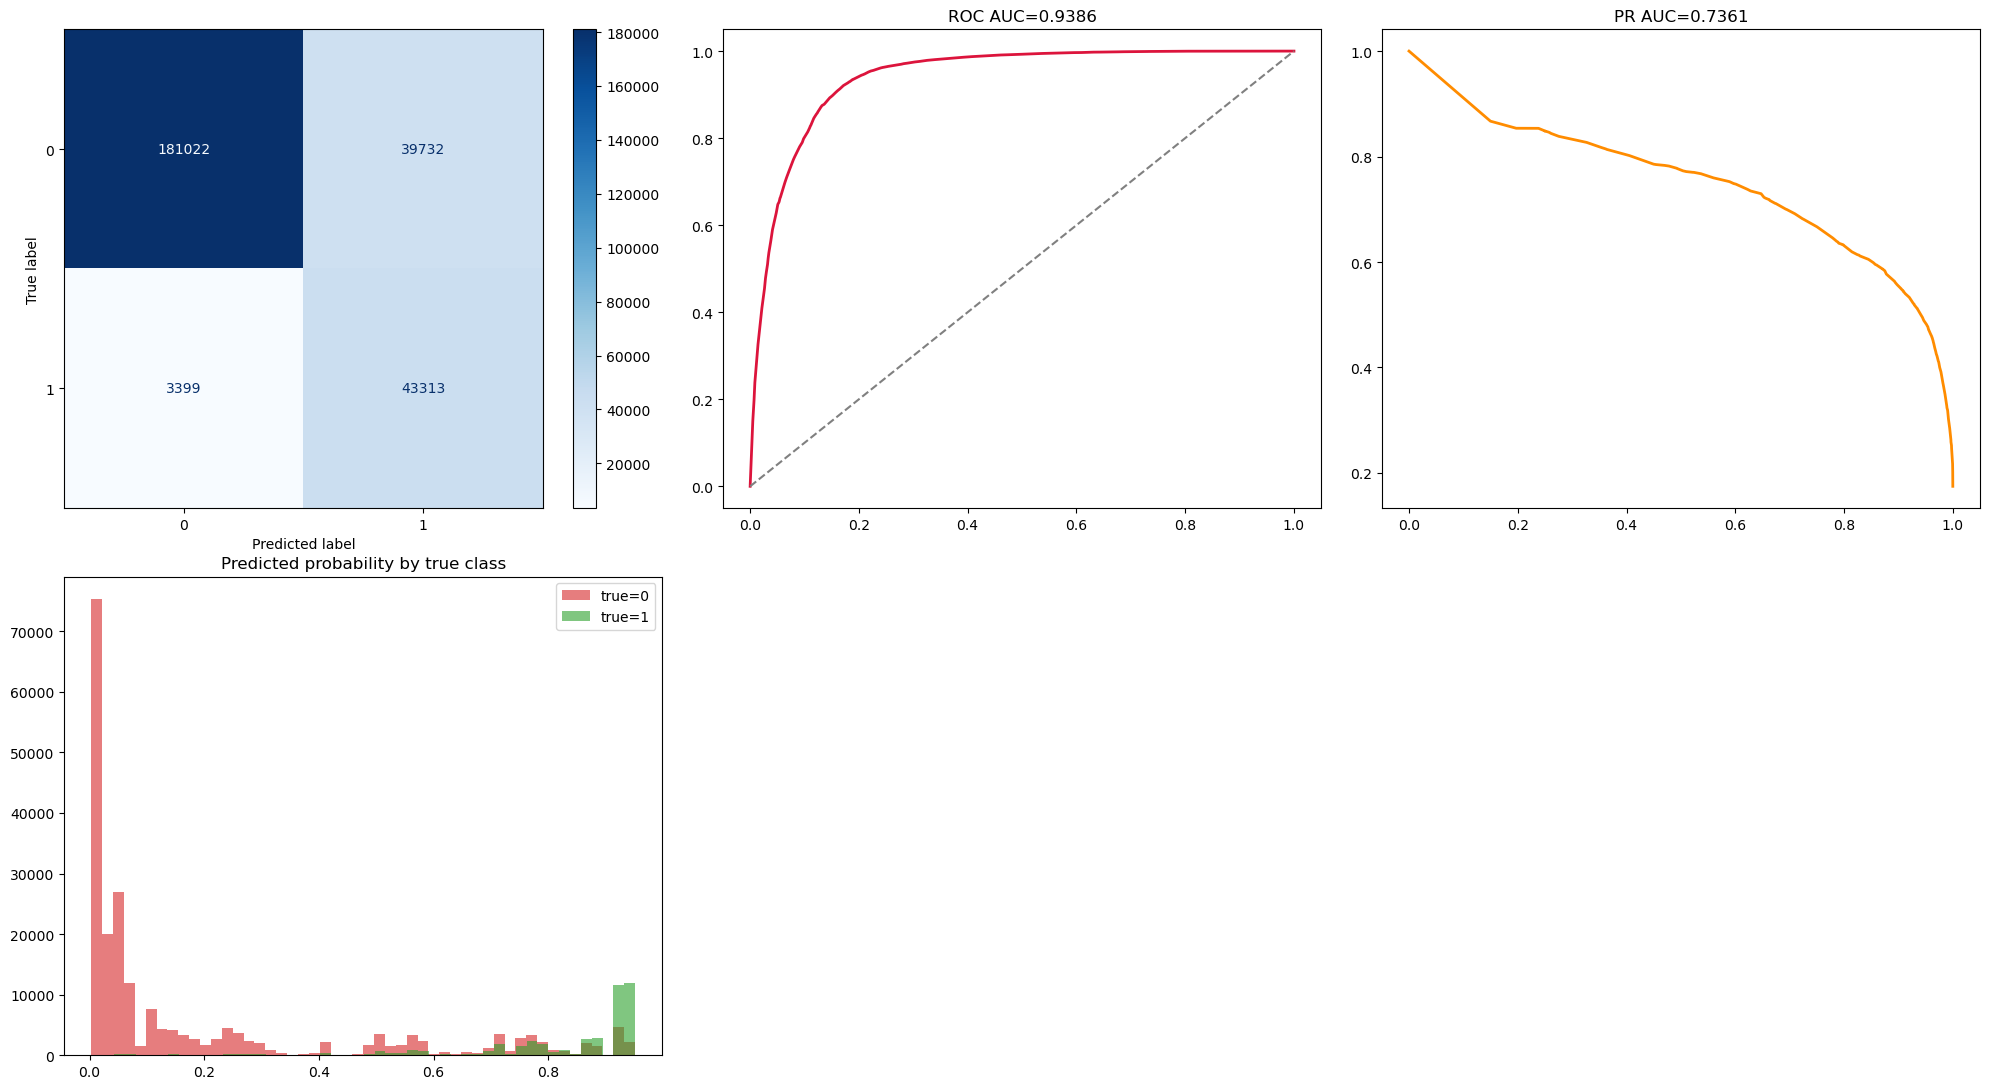

✅ Dashboard generated.


In [10]:
if DO_HOLDOUT and X_holdout is not None:
    holdout_proba = BEST_PIPELINE.predict_proba(X_holdout)[:, 1]
    holdout_preds = (holdout_proba >= 0.5).astype(int)
    y_t = y_holdout.to_numpy(dtype=int)
    ext = BEST_PIPELINE.named_steps['extractor']
    sel = BEST_PIPELINE.named_steps['selector']
    mdl = BEST_PIPELINE.named_steps['model']
    enc_names = list(ext.preprocessor_.get_feature_names_out())
    sel_names = [n for n, m in zip(enc_names, sel.get_support()) if m]
    print(f'🔎 Selector kept {len(sel_names)}/{len(enc_names)} encoded columns.')
    fpr, tpr, _ = roc_curve(y_t, holdout_proba)
    prec, rec, _ = precision_recall_curve(y_t, holdout_proba)
    fig = plt.figure(figsize=(20, 11))
    gs = fig.add_gridspec(2, 3)
    ConfusionMatrixDisplay.from_predictions(y_t, holdout_preds, cmap='Blues', ax=fig.add_subplot(gs[0, 0]), values_format='d')
    ax = fig.add_subplot(gs[0, 1]); ax.plot(fpr, tpr, lw=2, color='crimson')
    ax.set_title(f'ROC AUC={roc_auc_score(y_t, holdout_proba):.4f}'); ax.plot([0, 1], [0, 1], ls='--', c='gray')
    ax = fig.add_subplot(gs[0, 2]); ax.plot(rec, prec, lw=2, color='darkorange')
    ax.set_title(f'PR AUC={average_precision_score(y_t, holdout_proba):.4f}')
    ax = fig.add_subplot(gs[1, 0])
    ax.hist(holdout_proba[y_t == 0], bins=50, alpha=0.6, color='tab:red', label='true=0')
    ax.hist(holdout_proba[y_t == 1], bins=50, alpha=0.6, color='tab:green', label='true=1')
    ax.legend(); ax.set_title('Predicted probability by true class')
    fig.tight_layout(); plt.show()
    print('✅ Dashboard generated.')
else:
    holdout_proba, holdout_preds, y_t = None, None, None

# Advanced EDA & **Interactive** Prediction Analysis
Static rankings first, then the interactive Analysis Studio (compare features, filter derived/original groups, sweep thresholds & segments).

In [11]:
ranker = SignalRanker(y=y_train)
signal_table = ranker.rank(X_train, n_sample=5000 if SMOKE_TEST else 60000, random_state=RANDOM_STATE)
display(signal_table.head(15).style.background_gradient(
    cmap='magma', subset=['auc', 'cramers_v', 'iv', 'mi']).format(
    {'auc': '{:.4f}', 'cramers_v': '{:.4f}', 'iv': '{:.3f}', 'mi': '{:.4f}'}))

,feature,kind,auc,cramers_v,iv,mi
0,Environmental_Concern_Level,num,0.8388,0.4914,2.219,0.1233
1,Subsidy_Available,cat,0.7213,0.3489,1.898,0.0784
2,Annual_Income_USD,num,0.6758,0.2353,0.469,0.0409
3,Range_Anxiety_Level,cat,0.5435,0.1116,0.163,0.0079
4,Home_Charging_Possible,cat,0.5429,0.0708,0.037,0.0106
5,Daily_Commute_km,num,0.5263,0.0536,0.021,0.0019
6,City_Type,cat,0.5241,0.0380,0.010,0.0022
7,Age,num,0.5219,0.0645,0.029,0.0018
8,Charging_Stations_Near_Home,num,0.5200,0.0533,0.020,0.0037
9,id,num,0.5149,0.0421,0.012,0.0000


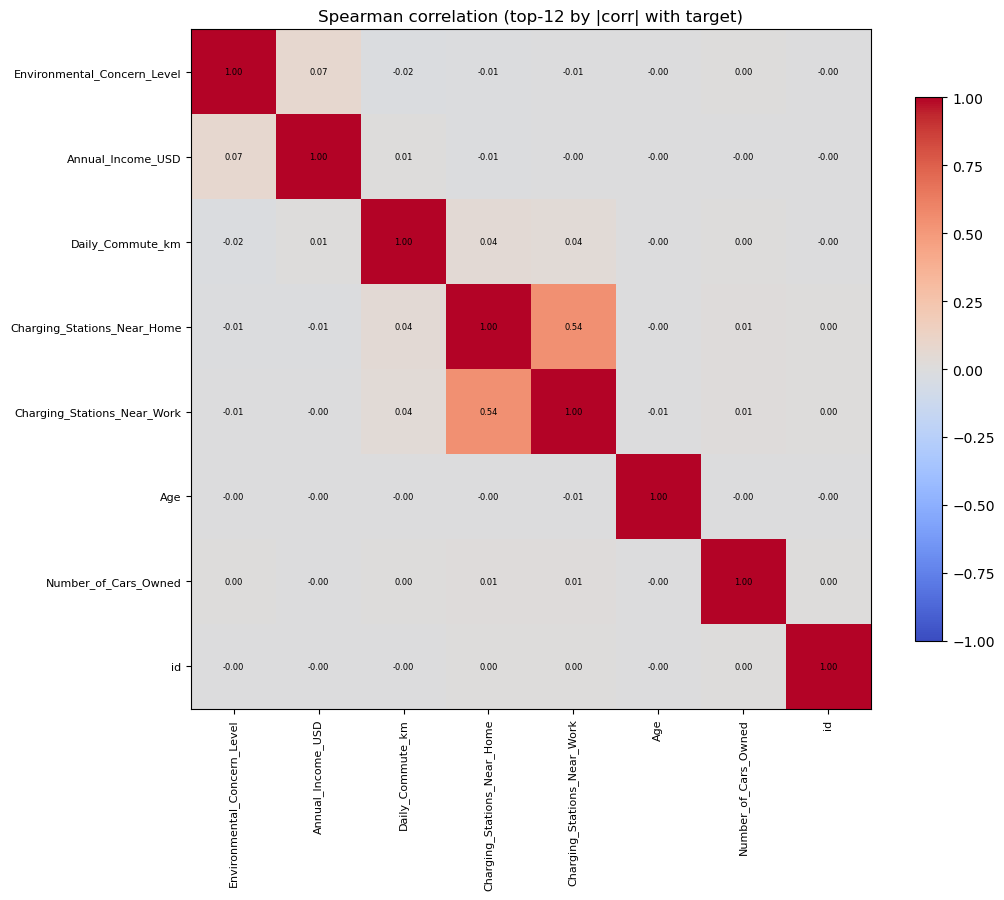

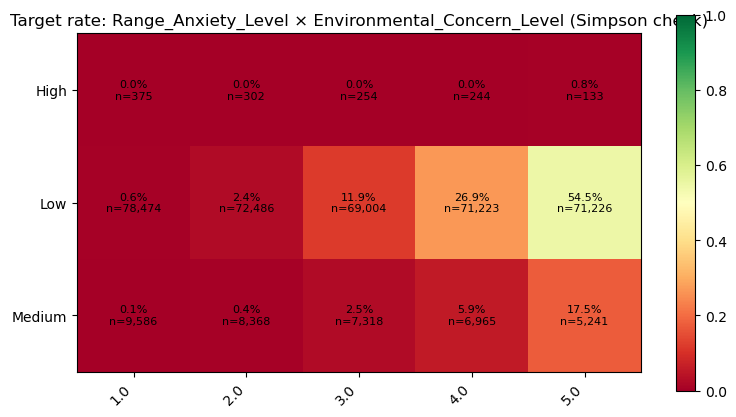

,feature,psi,flag
0,id,6.9008,HIGH
1,Annual_Income_USD,0.0001,ok
2,Charging_Stations_Near_Work,0.0001,ok
3,Range_Anxiety_Level,0.0001,ok
4,Daily_Commute_km,0.0001,ok
5,Number_of_Cars_Owned,0.0000,ok
6,Age,0.0000,ok
7,Charging_Stations_Near_Home,0.0000,ok
8,Current_Car_Type,0.0000,ok
9,Subsidy_Available,0.0000,ok


In [12]:
studio = CorrelationStudio(X_train, y=y_train)
studio.plot_heatmap(top_k=12, method='spearman')
if 'Range_Anxiety_Level' in X_train.columns and 'Environmental_Concern_Level' in X_train.columns:
    studio.interaction_pivot('Range_Anxiety_Level', 'Environmental_Concern_Level', y_train)
if test_df is not None and hasattr(studio, 'drift_table'):
    drift = studio.drift_table(X_train, test_df)
    display(drift.head(15).style.background_gradient(cmap='YlOrRd', subset=['psi']).format({'psi': '{:.4f}'}))

In [13]:
studio_source_df = X_train.copy()
studio_source_df[TARGET_COL] = y_train.values
EDA_TARGET_OPTIONS = [TARGET_COL] + [c for c in X_train.columns if c not in ('id', TARGET_COL)]

analysis_studio = InteractiveAnalysisStudio(
    X_df=X_train,
    y=y_train,
    extractor=BEST_PIPELINE.named_steps['extractor'],
    pipeline=BEST_PIPELINE,
    eval_df=X_holdout if DO_HOLDOUT else None,
    eval_y=y_holdout.to_numpy() if DO_HOLDOUT else None,
    eval_proba=holdout_proba if DO_HOLDOUT else None,
    random_state=RANDOM_STATE,
    source_df=studio_source_df,
    default_target=TARGET_COL,
    target_options=EDA_TARGET_OPTIONS,
)
studio_controls = analysis_studio.make_controls()
print('🎛️ Analysis Studio ready — pick independent features (A/B) and dependent variable, then run the panel cells below.')

🎛️ Analysis Studio ready — pick independent features (A/B) and dependent variable, then run the panel cells below.


In [14]:
if WIDGETS_AVAILABLE:
    compare_out = widgets.interactive_output(
        analysis_studio.update_compare,
        {'feature_a': studio_controls['feature_a'],
         'feature_b': studio_controls['feature_b'],
         'dependent': studio_controls['dependent'],
         'n_sample': studio_controls['n_sample']})
    display(widgets.HBox([
        studio_controls['feature_a'],
        studio_controls['feature_b'],
        studio_controls['dependent'],
        studio_controls['n_sample'],
    ]), compare_out)
else:
    analysis_studio.update_compare('Annual_Income_USD', 'Buy_Score', TARGET_COL, 20000)

Output()

In [15]:
if WIDGETS_AVAILABLE:
    imp_out = widgets.interactive_output(
        analysis_studio.update_importance,
        {'origin_filter': studio_controls['origin_filter'],
         'top_n': studio_controls['top_n']})
    display(widgets.HBox([studio_controls['origin_filter'], studio_controls['top_n']]), imp_out)
else:
    analysis_studio.update_importance(('original', 'screenshot', 'recipe'), 15)

Output()

In [16]:
if WIDGETS_AVAILABLE:
    diag_out = widgets.interactive_output(
        analysis_studio.update_diag,
        {'threshold': studio_controls['threshold'],
         'segment': studio_controls['segment']})
    display(widgets.HBox([studio_controls['threshold'], studio_controls['segment']]), diag_out)
else:
    analysis_studio.update_diag(0.5, 'all')

Output()

# Stacking Guidance Notes (notes only — NO stacking here)

In [17]:
if DO_HOLDOUT and holdout_proba is not None:
    hints = []
    rep = pd.DataFrame(classification_report(y_t, holdout_preds, target_names=['no_buy', 'buy'], output_dict=True)).T
    if rep.loc['buy', 'recall'] < 0.75:
        hints.append('RF misses minority buyers → add a calibrated linear model as a future stack base.')
    gap = SEARCH_SCORE - roc_auc_score(y_t, holdout_proba)
    if gap > 0.05:
        hints.append('Train/CV vs holdout gap → include a high-bias member for diversity.')
    print('📌 STACKING NOTES (do NOT stack in this notebook):')
    for h in hints:
        print(' •', h)
else:
    print('⚠️ Skipped stacking notes (no holdout).')

📌 STACKING NOTES (do NOT stack in this notebook):


# Optional Interactive Unsupervised Lab (gated by `RUN_CLUSTER_EXPLORER`)

In [ ]:
if RUN_CLUSTER_EXPLORER and WIDGETS_AVAILABLE and 'BEST_PIPELINE' in globals():
    cluster_explorer = ClusterExplorer(X_df=X, y=y, extractor=BEST_PIPELINE.named_steps['extractor'], random_state=RANDOM_STATE)
    cluster_controls = cluster_explorer.make_controls()
    cluster_out = widgets.interactive_output(cluster_explorer.update, cluster_controls)
    display(widgets.HBox([cluster_controls['method'], cluster_controls['reduction'], cluster_controls['n_clusters'], cluster_controls['scale'], cluster_controls['color_by'], cluster_controls['sample_size']]))
    display(cluster_controls['features'], cluster_out)
elif RUN_CLUSTER_EXPLORER and 'BEST_PIPELINE' in globals():
    cluster_explorer = ClusterExplorer(X_df=X, y=y, extractor=BEST_PIPELINE.named_steps['extractor'], random_state=RANDOM_STATE)
    cluster_explorer.update(method='kmeans', reduction='pca', n_clusters=4, features=tuple(cluster_explorer.default_features_), scale=True, color_by='__target__', sample_size=15000)
else:
    print('Cluster explorer skipped.')

SelectMultiple(description='Features:', index=(1, 0, 2, 12, 6, 11, 34, 27), options=('Age', 'Annual_Income_USD…

Output()